In [2]:
import pandas as pd

sheets = pd.read_excel("TravelAgency_StarSchema (version 1).xlsx", sheet_name=None)

fact = sheets["FactBookings"]
hotels = sheets["DimHotels"]
tickets = sheets["DimTickets"]
visa = sheets["DimVisaApplications"]

In [10]:
df.isnull().sum()

BookingID             0
CustomerID            0
VisaID                0
HotelID               0
TicketID              0
BookingDate           0
HotelName             0
City                  0
Country               0
NightlyRate           0
FromCity              0
ToCity                0
DepartureDate         0
Airline               0
Class                 0
TicketCost            0
VisaType              0
Status                0
CountryApplied        0
SubmissionDate        0
ApprovedDate        608
Fees                  0
proccessinf time      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
top_countries = df["CountryApplied"].value_counts().reset_index()
top_countries.columns = ["Country", "Applications"]
top_countries.head(10)

,Country,Applications
0,France,541
1,USA,523
2,Canada,493
3,UAE,493
4,Germany,492
5,UK,458


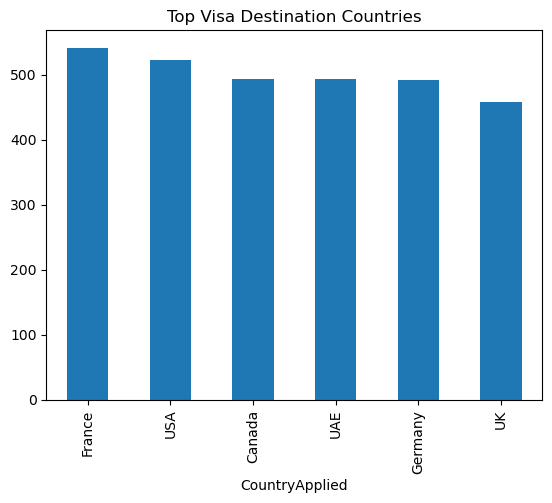

In [9]:
import matplotlib.pyplot as plt

df["CountryApplied"].value_counts().head(10).plot(kind="bar")
plt.title("Top Visa Destination Countries")
plt.show()

In [10]:
print(f"Total Visa Revenue = {df['Fees'].sum()}")

Total Visa Revenue = 3712274.0


In [11]:
df["SubmissionDate"] = pd.to_datetime(df["SubmissionDate"])
monthly_apps = df.groupby(df["SubmissionDate"].dt.to_period("M"))["VisaID"].count()
monthly_apps

SubmissionDate
2024-07     78
2024-08    264
2024-09    254
2024-10    249
2024-11    203
2024-12    255
2025-01    272
2025-02    225
2025-03    216
2025-04    257
2025-05    246
2025-06    294
2025-07    187
Freq: M, Name: VisaID, dtype: int64

In [16]:
df["City"].value_counts().idxmax()

'Cairo'

In [12]:
df["Country"].value_counts().idxmax()

'Congo'

In [13]:
customers = sheets["DimCustomers"]
customers.head()


,CustomerID,Name,Gender,Country,Email,PhoneNumber
0,CUST0000,Norma Fisher,Female,Gabon,bsellers@yahoo.com,001-273-949-1441x969
1,CUST0001,Jorge Sullivan,Female,Namibia,robert39@yahoo.com,001-196-911-4038
2,CUST0002,Elizabeth Woods,Male,Mayotte,oturner@garcia.com,+1-819-651-9927
3,CUST0003,Susan Wagner,Female,Eritrea,gregory93@ramsey.com,001-269-676-7086x963
4,CUST0004,Peter Montgomery,Female,Norfolk Island,steven85@yahoo.com,701.156.5273x9167


In [14]:
df = df.merge(customers, on="CustomerID", how="left")

In [15]:
df.groupby("Gender")["BookingID"].nunique()

Gender
Female    1568
Male      1432
Name: BookingID, dtype: int64

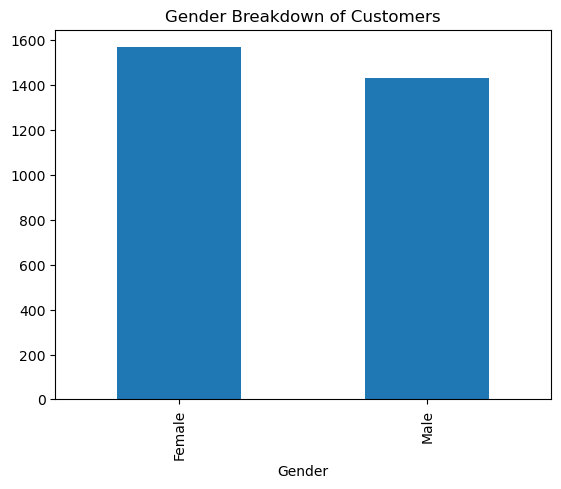

In [16]:
import matplotlib.pyplot as plt

df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Breakdown of Customers")
plt.show()

In [17]:
df["TotalSpent"] = df["Fees"] + df["TicketCost"] + df["NightlyRate"]

In [18]:
customer_spending = df.groupby("CustomerID")["TotalSpent"].sum()
customer_spending
customer_spending.sort_values(ascending=False).head(10)

CustomerID
CUST1654    29262.0
CUST2249    29084.0
CUST2258    28505.0
CUST1204    26412.0
CUST0180    24934.0
CUST2923    24855.0
CUST2300    24194.0
CUST2442    24082.0
CUST1278    23706.0
CUST0754    23363.0
Name: TotalSpent, dtype: float64

In [19]:
visa_only = df[
    (df["VisaID"].notna()) &
    (df["HotelID"].isna()) &
    (df["TicketID"].isna())
]

In [20]:
visa_only["CustomerID"].unique()

array([], dtype=object)

In [21]:
approved = df[df["Status"] == "Approved"]


In [22]:
approved_with_travel = approved[
    (approved["TicketID"].notna()) &
    (approved["HotelID"].notna())
]

In [23]:
percentage = len(approved_with_travel) / len(approved) * 100
percentage

100.0

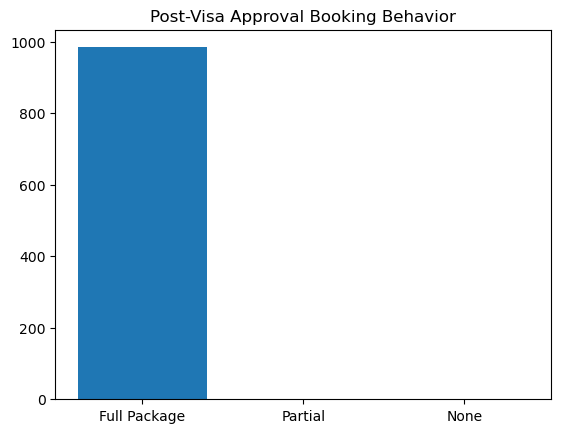

In [24]:
import matplotlib.pyplot as plt

labels = ["Full Package", "Partial", "None"]
values = [
    len(approved_with_travel),
    len(approved) - len(approved_with_travel),
    0
]

plt.bar(labels, values)
plt.title("Post-Visa Approval Booking Behavior")
plt.show()

In [25]:
df["TotalCost"] = df["Fees"] + df["NightlyRate"] + df["TicketCost"]

In [26]:
average_cost = df["TotalCost"].mean()
print(f"Average total booking cost = {average_cost}")

Average total booking cost = 4687.36


In [27]:
approved = df[df["Status"] == "Approved"]

In [28]:
approved["City"].value_counts().idxmax()

'Cairo'

In [29]:
df["VisaApproved"] = df["Status"].apply(lambda x: 1 if x == "Approved" else 0)

In [30]:
df[["VisaApproved", "NightlyRate"]].corr()

,VisaApproved,NightlyRate
VisaApproved,1.000000,0.005394
NightlyRate,0.005394,1.000000


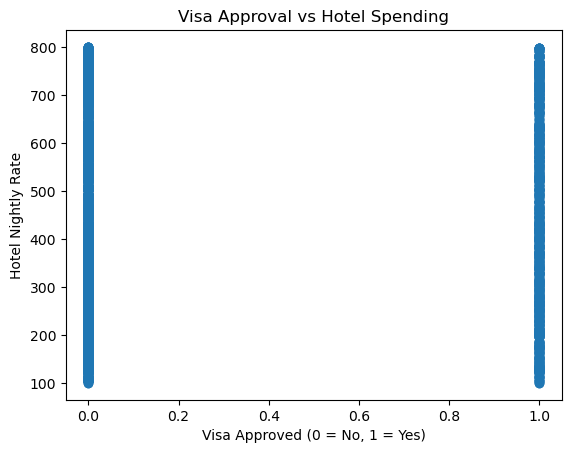

In [31]:
plt.scatter(df["VisaApproved"], df["NightlyRate"])
plt.title("Visa Approval vs Hotel Spending")
plt.xlabel("Visa Approved (0 = No, 1 = Yes)")
plt.ylabel("Hotel Nightly Rate")
plt.show()